# Monolithic vs Modular — 실전 비교

> 같은 데이터, 같은 feature로 Monolithic(단일 LightGBM)과 Modular(Additive)를 직접 돌려서 비교한다.

## 이 노트북에서 확인할 것

| 항목 | 내용 |
|------|------|
| **1. Monolithic 학습** | 전체 feature → 하나의 LightGBM |
| **2. Additive 학습** | 도메인별 독립 모델 → 점수 합산 |
| **3. 성능 비교** | 같은 Test셋에서 AUC, PR-AUC, Brier |
| **4. 확장성 시연** | 컴포넌트 추가/제거 → Monolithic은 못 하는 것 |
| **5. 설명가능성** | 도메인별 기여도 분해 → Monolithic은 못 하는 것 |

In [1]:
# ─── 패키지 설치 & 환경 설정 (Colab) ───
!pip install -q lightgbm

# 한글 폰트 (Colab)
!apt-get -qq install -y fonts-nanum > /dev/null 2>&1
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("환경 설정 완료")

환경 설정 완료


In [2]:
# ─── CSV 업로드 (Colab) ───
# 방법 1: 아래 코드 실행 후 data 폴더의 CSV 11개를 모두 선택
from google.colab import files
print("data/ 폴더의 CSV 파일 11개를 모두 선택하세요:")
uploaded = files.upload()
print(f"\n업로드 완료: {len(uploaded)}개 파일")

data/ 폴더의 CSV 파일 11개를 모두 선택하세요:


Saving behavior_monthly_observation.csv to behavior_monthly_observation.csv
Saving core_policy.csv to core_policy.csv
Saving core_policyholder.csv to core_policyholder.csv
Saving core_underwriting_assessment.csv to core_underwriting_assessment.csv
Saving medical_claim_event.csv to medical_claim_event.csv
Saving medical_diagnosis_event.csv to medical_diagnosis_event.csv
Saving medical_hospitalization_event.csv to medical_hospitalization_event.csv
Saving modeling_component_registry.csv to modeling_component_registry.csv
Saving modeling_feature_registry.csv to modeling_feature_registry.csv
Saving modeling_outcome_high_cost_event.csv to modeling_outcome_high_cost_event.csv
Saving modeling_target_definition.csv to modeling_target_definition.csv

업로드 완료: 11개 파일


---

## 1. 데이터 로드 & Feature 추출

5개 도메인의 feature를 추출한다. Monolithic과 Additive **둘 다 같은 feature를 사용**한다.

In [4]:
# ─── Feature Pipeline (인라인) ───
# 원시 CSV → 도메인별 feature DataFrame 생성

# CSV 로드
_cache = {}
def _load(name):
    if name not in _cache:
        _cache[name] = pd.read_csv(f"{name}.csv")
    return _cache[name]

_KEY_COLS = {"policyholder_id", "anchor_month"}

def get_feature_columns(df):
    return [c for c in df.columns if c not in _KEY_COLS]

def _month_offset(anchor, months):
    return pd.Timestamp(anchor) - pd.DateOffset(months=months)

# ── 도메인 1: 인구통계 + UW ──
def extract_demographics_uw(outcome_df):
    ph = _load("core_policyholder")
    policy = _load("core_policy")
    uw = _load("core_underwriting_assessment")
    policy_uw = policy.merge(uw, on="policy_id", how="left")
    uw_agg = policy_uw.groupby("policyholder_id").agg(
        uw_class_best=("uw_class", "first"), extra_rate_flag=("extra_rate_flag", "max"),
        questionnaire_score_band=("questionnaire_score_band", "first"),
        bp_band=("bp_band", "first"), glucose_band=("glucose_band", "first"),
        cholesterol_band=("cholesterol_band", "first"),
    ).reset_index()
    demo = ph.merge(uw_agg, on="policyholder_id", how="left")
    demo["age"] = 2022 - demo["birth_year"]
    demo.drop(columns=["birth_year", "synthetic_household_id", "created_at"], inplace=True, errors="ignore")
    cat_cols = ["sex_code", "region_tier", "occupation_class", "income_band", "bmi_band",
                "uw_class_best", "questionnaire_score_band", "bp_band", "glucose_band", "cholesterol_band"]
    for col in cat_cols:
        if col in demo.columns:
            demo[col] = LabelEncoder().fit_transform(demo[col].fillna("unknown").astype(str))
    for col in ["smoker_flag", "family_history_cancer_flag", "family_history_cv_flag", "extra_rate_flag"]:
        if col in demo.columns:
            demo[col] = demo[col].astype(int)
    return outcome_df[["policyholder_id", "anchor_month"]].merge(demo, on="policyholder_id", how="left")

# ── 도메인 2: 의료이력 ──
def extract_medical(outcome_df):
    dx = _load("medical_diagnosis_event").copy()
    hosp = _load("medical_hospitalization_event").copy()
    dx["diagnosis_date"] = pd.to_datetime(dx["diagnosis_date"])
    hosp["admission_date"] = pd.to_datetime(hosp["admission_date"])
    outcome = outcome_df[["policyholder_id", "anchor_month"]].copy()
    outcome["anchor_dt"] = pd.to_datetime(outcome["anchor_month"])
    # 진단
    dx_m = outcome.merge(dx, on="policyholder_id", how="left")
    dx_m = dx_m[dx_m["diagnosis_date"] < dx_m["anchor_dt"]]
    dx_hist = dx_m.groupby(["policyholder_id", "anchor_month"]).agg(
        hist_dx_count=("diagnosis_event_id", "count"), hist_chronic_count=("chronic_flag", "sum"),
        has_cancer_hx=("diagnosis_group", lambda x: int((x == "cancer").any())),
        has_cv_hx=("diagnosis_group", lambda x: int((x == "cardiovascular").any())),
    ).reset_index()
    dx_3m = dx_m[dx_m["diagnosis_date"] >= dx_m["anchor_dt"] - pd.DateOffset(months=3)].groupby(
        ["policyholder_id", "anchor_month"]).agg(
        rdx_count_3m=("diagnosis_event_id", "count"), rdx_chronic_3m=("chronic_flag", "sum")).reset_index()
    dx_6m = dx_m[dx_m["diagnosis_date"] >= dx_m["anchor_dt"] - pd.DateOffset(months=6)].groupby(
        ["policyholder_id", "anchor_month"]).agg(rdx_count_6m=("diagnosis_event_id", "count")).reset_index()
    # 입원
    ho_m = outcome.merge(hosp, on="policyholder_id", how="left")
    ho_m = ho_m[ho_m["admission_date"] < ho_m["anchor_dt"]]
    ho_hist = ho_m.groupby(["policyholder_id", "anchor_month"]).agg(
        hist_hosp_count=("hospitalization_event_id", "count"), surgery_count=("surgery_flag", "sum"),
        icu_ever=("icu_flag", "max")).reset_index()
    ho_3m = ho_m[ho_m["admission_date"] >= ho_m["anchor_dt"] - pd.DateOffset(months=3)].groupby(
        ["policyholder_id", "anchor_month"]).agg(
        rhosp_count_3m=("hospitalization_event_id", "count"), rhosp_los_3m=("length_of_stay_days", "sum")).reset_index()
    ho_6m = ho_m[ho_m["admission_date"] >= ho_m["anchor_dt"] - pd.DateOffset(months=6)].groupby(
        ["policyholder_id", "anchor_month"]).agg(rhosp_los_6m=("length_of_stay_days", "sum")).reset_index()
    result = outcome[["policyholder_id", "anchor_month"]].copy()
    for df in [dx_hist, dx_3m, dx_6m, ho_hist, ho_3m, ho_6m]:
        result = result.merge(df, on=["policyholder_id", "anchor_month"], how="left")
    result.drop(columns=["anchor_dt"], inplace=True, errors="ignore")
    result.fillna(0, inplace=True)
    return result

# ── 도메인 3: 청구 ──
def extract_claim(outcome_df):
    cl = _load("medical_claim_event").copy()
    cl["service_date"] = pd.to_datetime(cl["service_date"])
    outcome = outcome_df[["policyholder_id", "anchor_month"]].copy()
    outcome["anchor_dt"] = pd.to_datetime(outcome["anchor_month"])
    cl_m = outcome.merge(cl, on="policyholder_id", how="left")
    cl_m = cl_m[cl_m["service_date"] < cl_m["anchor_dt"]]
    cl_hist = cl_m.groupby(["policyholder_id", "anchor_month"]).agg(
        hist_claim_count=("claim_id", "count"), hist_claim_amount=("claim_amount_paid", "sum")).reset_index()
    cl_3m = cl_m[cl_m["service_date"] >= cl_m["anchor_dt"] - pd.DateOffset(months=3)].groupby(
        ["policyholder_id", "anchor_month"]).agg(
        rcl_count_3m=("claim_id", "count"), rcl_amount_3m=("claim_amount_paid", "sum"),
        rcl_high_sev_3m=("high_severity_service_flag", "sum")).reset_index()
    cl_6m = cl_m[cl_m["service_date"] >= cl_m["anchor_dt"] - pd.DateOffset(months=6)].groupby(
        ["policyholder_id", "anchor_month"]).agg(
        rcl_count_6m=("claim_id", "count"), rcl_amount_6m=("claim_amount_paid", "sum")).reset_index()
    result = outcome[["policyholder_id", "anchor_month"]].copy()
    for df in [cl_hist, cl_3m, cl_6m]:
        result = result.merge(df, on=["policyholder_id", "anchor_month"], how="left")
    result.drop(columns=["anchor_dt"], inplace=True, errors="ignore")
    result.fillna(0, inplace=True)
    return result

# ── 도메인 4: 보험계약 ──
def extract_policy(outcome_df):
    pol = _load("core_policy").copy()
    pol_agg = pol.groupby("policyholder_id").agg(
        n_policies=("policy_id", "count"), premium_sum=("premium_amount", "sum"),
        premium_mean=("premium_amount", "mean"), face_sum=("face_amount", "sum"),
        face_mean=("face_amount", "mean"), policy_month_max=("policy_month", "max"),
        renewable_count=("renewable_flag", "sum"), lapse_count=("lapse_flag", "sum")).reset_index()
    mode_cols = pol.groupby("policyholder_id").agg(
        product_type_main=("product_type", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else "unknown"),
        coverage_type_main=("coverage_type", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else "unknown"),
        channel_main=("distribution_channel", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else "unknown")).reset_index()
    pol_feat = pol_agg.merge(mode_cols, on="policyholder_id", how="left")
    for col in ["product_type_main", "coverage_type_main", "channel_main"]:
        pol_feat[col] = LabelEncoder().fit_transform(pol_feat[col].astype(str))
    for col in ["renewable_count", "lapse_count"]:
        pol_feat[col] = pol_feat[col].astype(int)
    result = outcome_df[["policyholder_id", "anchor_month"]].merge(pol_feat, on="policyholder_id", how="left")
    result.fillna(0, inplace=True)
    return result

# ── 도메인 5: 행동 ──
def extract_behavior(outcome_df):
    beh = _load("behavior_monthly_observation").copy()
    beh["observation_month"] = pd.to_datetime(beh["observation_month"])
    outcome = outcome_df[["policyholder_id", "anchor_month"]].copy()
    outcome["anchor_dt"] = pd.to_datetime(outcome["anchor_month"])
    merged = outcome.merge(beh, on="policyholder_id", how="left")
    merged = merged[merged["observation_month"] < merged["anchor_dt"]]
    beh_agg = merged.groupby(["policyholder_id", "anchor_month"]).agg(
        avg_sleep=("sleep_irregularity_score", "mean"), avg_mobility=("mobility_change_score", "mean"),
        avg_stress=("stress_proxy_score", "mean"), avg_adherence=("medication_adherence_score", "mean"),
        avg_wellness=("wellness_program_engagement_score", "mean"),
        avg_app_days=("app_active_days", "mean"), wearable_flag=("wearable_source_flag", "max"),
        checkup_count=("preventive_checkup_flag", "sum")).reset_index()
    recent_3m = merged[merged["observation_month"] >= merged["anchor_dt"] - pd.DateOffset(months=3)].groupby(
        ["policyholder_id", "anchor_month"]).agg(
        stress_3m=("stress_proxy_score", "mean"), sleep_3m=("sleep_irregularity_score", "mean"),
        mobility_3m=("mobility_change_score", "mean")).reset_index()
    result = outcome[["policyholder_id", "anchor_month"]].copy()
    result = result.merge(beh_agg, on=["policyholder_id", "anchor_month"], how="left")
    result = result.merge(recent_3m, on=["policyholder_id", "anchor_month"], how="left")
    result.drop(columns=["anchor_dt"], inplace=True, errors="ignore")
    result["has_behavior_data"] = result["avg_stress"].notna().astype(int)
    result["wearable_flag"] = result["wearable_flag"].fillna(False).astype(int)
    result.fillna(0, inplace=True)
    return result

# ── 전체 파이프라인 ──
DOMAIN_EXTRACTORS = {
    "demographics_uw": extract_demographics_uw, "medical": extract_medical,
    "claim": extract_claim, "policy": extract_policy, "behavior": extract_behavior,
}
ALL_DOMAINS = list(DOMAIN_EXTRACTORS.keys())

def build_all_features(outcome_df, domains=None):
    if domains is None:
        domains = ALL_DOMAINS
    features = {}
    for domain in domains:
        print(f"  [{domain}] 추출 중...", end=" ")
        df = DOMAIN_EXTRACTORS[domain](outcome_df)
        features[domain] = df
        print(f"{len(get_feature_columns(df))} features")
    target = outcome_df.set_index(["policyholder_id", "anchor_month"])["high_cost_event_flag"].astype(int)
    return features, target

def temporal_split(outcome_df):
    month = pd.to_datetime(outcome_df["anchor_month"]).dt.month
    return (outcome_df[month <= 8].reset_index(drop=True),
            outcome_df[month.isin([9, 10])].reset_index(drop=True),
            outcome_df[month.isin([11, 12])].reset_index(drop=True))

print("Feature Pipeline 정의 완료")

Feature Pipeline 정의 완료


In [5]:
# ─── 데이터 로드 & 시간 분할 & Feature 추출 ───

outcome = pd.read_csv("modeling_outcome_high_cost_event.csv")
train_df, valid_df, test_df = temporal_split(outcome)

print(f"전체: {len(outcome):,}행")
print(f"Train (01~08월): {len(train_df):,}")
print(f"Valid (09~10월): {len(valid_df):,}")
print(f"Test  (11~12월): {len(test_df):,}")
print(f"양성률: {outcome['high_cost_event_flag'].mean():.1%}")

print("\n=== Train Feature 추출 ===")
feat_train, y_train = build_all_features(train_df)
print("\n=== Valid Feature 추출 ===")
feat_valid, y_valid = build_all_features(valid_df)
print("\n=== Test Feature 추출 ===")
feat_test, y_test = build_all_features(test_df)

# 도메인별 feature 수 확인
print("\n도메인별 feature 수:")
for domain in ALL_DOMAINS:
    fcols = get_feature_columns(feat_train[domain])
    print(f"  {domain:20s}: {len(fcols)}개")

전체: 720,000행
Train (01~08월): 480,000
Valid (09~10월): 120,000
Test  (11~12월): 120,000
양성률: 15.6%

=== Train Feature 추출 ===
  [demographics_uw] 추출 중... 15 features
  [medical] 추출 중... 13 features
  [claim] 추출 중... 7 features
  [policy] 추출 중... 11 features
  [behavior] 추출 중... 12 features

=== Valid Feature 추출 ===
  [demographics_uw] 추출 중... 15 features
  [medical] 추출 중... 13 features
  [claim] 추출 중... 7 features
  [policy] 추출 중... 11 features
  [behavior] 추출 중... 12 features

=== Test Feature 추출 ===
  [demographics_uw] 추출 중... 15 features
  [medical] 추출 중... 13 features
  [claim] 추출 중... 7 features
  [policy] 추출 중... 11 features
  [behavior] 추출 중... 12 features

도메인별 feature 수:
  demographics_uw     : 15개
  medical             : 13개
  claim               : 7개
  policy              : 11개
  behavior            : 12개


---

## 2. Monolithic 모델 (단일 LightGBM)

전체 feature를 **하나로 합쳐서** 하나의 LightGBM에 넣는 기존 방식.

```
[인구통계 + 의료 + 청구 + 보험 + 행동] → [하나의 LightGBM] → 확률
```

In [7]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def get_log_odds(model, X):
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    else:
        proba = np.clip(model.predict_proba(X)[:, 1], 1e-7, 1 - 1e-7)
        return np.log(proba / (1 - proba))

def evaluate(y_true, y_pred):
    return {
        "AUC-ROC": roc_auc_score(y_true, y_pred),
        "PR-AUC": average_precision_score(y_true, y_pred),
        "Brier": brier_score_loss(y_true, y_pred),
    }

print("유틸리티 함수 정의 완료")

유틸리티 함수 정의 완료


In [8]:
# ─── Monolithic: 전체 feature를 하나의 LightGBM에 ───

def build_monolithic_X(features_dict, domains):
    """도메인별 feature를 전부 합쳐서 하나의 행렬로"""
    arrays = []
    all_feature_names = []
    for domain in domains:
        df = features_dict[domain]
        fcols = get_feature_columns(df)
        arrays.append(df[fcols].values.astype(np.float32))
        all_feature_names.extend([f"{domain}__{c}" for c in fcols])
    return np.hstack(arrays), all_feature_names

# Train/Test 데이터 합치기
X_train_mono, feature_names = build_monolithic_X(feat_train, ALL_DOMAINS)
X_test_mono, _ = build_monolithic_X(feat_test, ALL_DOMAINS)

print(f"Monolithic feature 수: {X_train_mono.shape[1]}개")
print(f"Train: {X_train_mono.shape[0]:,}행 × {X_train_mono.shape[1]}열")

# LightGBM 학습 (Baseline과 비슷한 하이퍼파라미터)
mono_model = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6, num_leaves=31,
    min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=5.41,
    random_state=42, verbose=-1,
)

mono_model.fit(X_train_mono, y_train.values)
y_pred_mono = mono_model.predict_proba(X_test_mono)[:, 1]

metrics_mono = evaluate(y_test.values, y_pred_mono)

print(f"\n{'='*50}")
print(f"  Monolithic (LightGBM) 성능")
print(f"{'='*50}")
for k, v in metrics_mono.items():
    print(f"  {k}: {v:.4f}")

Monolithic feature 수: 58개
Train: 480,000행 × 58열

  Monolithic (LightGBM) 성능
  AUC-ROC: 0.9431
  PR-AUC: 0.7925
  Brier: 0.0953


---

## 3. Additive 모델 (모듈형)

각 도메인이 **독립적으로** 위험 점수를 출력하고, **단순 합산**으로 최종 확률을 산출.

```
[인구통계 모델] → 점수 +1.2 ─┐
[의료이력 모델] → 점수 +3.5 ─┤
[청구 모델]    → 점수 +0.8 ─┼→ 합산 → sigmoid → 최종 확률
[보험 모델]    → 점수 -0.3 ─┤
[행동 모델]    → 점수 +0.5 ─┘
```

Monolithic과 **같은 feature, 같은 데이터**를 사용하지만, 구조만 다르다.

In [9]:
# ─── Additive 모델 핵심 함수 ───

def sigmoid(x):
    """log-odds → 확률 변환"""
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))


def get_log_odds(model, X):
    """모델에서 log-odds 점수 추출"""
    if hasattr(model, "decision_function"):
        return model.decision_function(X)  # LogisticRegression
    else:
        proba = np.clip(model.predict_proba(X)[:, 1], 1e-7, 1 - 1e-7)
        return np.log(proba / (1 - proba))  # EBM, LightGBM


def evaluate(y_true, y_pred):
    """3개 평가 지표 계산"""
    return {
        "AUC-ROC": roc_auc_score(y_true, y_pred),
        "PR-AUC": average_precision_score(y_true, y_pred),
        "Brier": brier_score_loss(y_true, y_pred),
    }


def train_additive(feat_train, y_train, feat_test, y_test, domains):
    """
    주어진 도메인 목록으로 Additive 모델 학습 & 평가.
    반환: metrics, 학습된 컴포넌트들, 도메인별 점수
    """
    components = {}

    for domain in domains:
        fcols = get_feature_columns(feat_train[domain])
        X_tr = feat_train[domain][fcols].values.astype(np.float32)

        # LogisticRegression (모든 도메인에 동일하게 적용 — 단순화)
        model = LogisticRegression(max_iter=1000, C=1.0)
        model.fit(X_tr, y_train.values)
        components[domain] = model

    # 합산 → 확률
    total_score = np.zeros(len(y_test))
    domain_scores = {}

    for domain in domains:
        fcols = get_feature_columns(feat_test[domain])
        X_te = feat_test[domain][fcols].values.astype(np.float32)
        score = get_log_odds(components[domain], X_te)
        total_score += score
        domain_scores[domain] = score

    y_pred = sigmoid(total_score)
    metrics = evaluate(y_test.values, y_pred)

    return metrics, components, domain_scores


print("Additive 모델 함수 정의 완료")

Additive 모델 함수 정의 완료


## 4. 성능 비교: Monolithic vs Additive

In [10]:
# 5개 도메인 전체로 Additive 모델 학습
metrics_full, components_full, scores_full = train_additive(
    feat_train, y_train, feat_test, y_test, domains=ALL_DOMAINS
)

# 기준선과 비교 (Monolithic은 위에서 직접 돌린 결과 사용)
baselines = {"AUC-ROC": 0.75, "PR-AUC": 0.40, "Brier": 0.13}

print("=" * 60)
print("  Monolithic vs Additive 성능 비교")
print("=" * 60)
print(f"{'':20s} {'AUC-ROC':>10s} {'PR-AUC':>10s} {'Brier':>10s}")
print("-" * 60)
print(f"{'기준선 (최소)':20s} {baselines['AUC-ROC']:>10.4f} {baselines['PR-AUC']:>10.4f} {baselines['Brier']:>10.4f}")
print(f"{'Monolithic (LightGBM)':20s} {metrics_mono['AUC-ROC']:>10.4f} {metrics_mono['PR-AUC']:>10.4f} {metrics_mono['Brier']:>10.4f}")
print(f"{'Additive (5개)':20s} {metrics_full['AUC-ROC']:>10.4f} {metrics_full['PR-AUC']:>10.4f} {metrics_full['Brier']:>10.4f}")
print("-" * 60)

delta = metrics_full['AUC-ROC'] - metrics_mono['AUC-ROC']
print(f"\n  AUC 차이: {delta:+.4f} {'(Additive가 높음)' if delta > 0 else '(Monolithic이 높음)'}")
print(f"  → 성능은 {'비슷' if abs(delta) < 0.02 else '차이 있음'}하지만,")
print(f"    Additive는 설명가능 + 확장가능 + 부분중단 가능!")

  Monolithic vs Additive 성능 비교
                        AUC-ROC     PR-AUC      Brier
------------------------------------------------------------
기준선 (최소)                 0.7500     0.4000     0.1300
Monolithic (LightGBM)     0.9431     0.7925     0.0953
Additive (5개)            0.9073     0.6927     0.1550
------------------------------------------------------------

  AUC 차이: -0.0357 (Monolithic이 높음)
  → 성능은 차이 있음하지만,
    Additive는 설명가능 + 확장가능 + 부분중단 가능!


---

## 5. 확장성 시연 — Monolithic은 못 하는 것

### 시연 A: 컴포넌트 추가

> 기존 4개 모델을 **재학습하지 않고**, 행동 컴포넌트만 추가하면 성능이 올라갈까?

- Additive: 행동 모델 하나만 학습 → 기존 점수에 더하기 → 끝
- Monolithic: 행동 feature 추가하려면? → **전체 59개+13개 = 72개 feature로 처음부터 재학습**

In [11]:
# ─── 시연 A: 4개 → 5개 컴포넌트 추가 ───

DOMAINS_WITHOUT_BEHAVIOR = ["demographics_uw", "medical", "claim", "policy"]

# Step 1: 4개 컴포넌트만으로 학습 & 평가
metrics_4, components_4, scores_4 = train_additive(
    feat_train, y_train, feat_test, y_test, domains=DOMAINS_WITHOUT_BEHAVIOR
)

# Step 2: 기존 4개는 그대로 두고, 행동 컴포넌트만 새로 학습
fcols_beh = get_feature_columns(feat_train["behavior"])
X_beh_train = feat_train["behavior"][fcols_beh].values.astype(np.float32)
X_beh_test = feat_test["behavior"][fcols_beh].values.astype(np.float32)

behavior_model = LogisticRegression(max_iter=1000, C=1.0)
behavior_model.fit(X_beh_train, y_train.values)

# Step 3: 기존 4개 점수에 행동 점수를 더하기만 하면 끝!
score_4_total = sum(scores_4[d] for d in DOMAINS_WITHOUT_BEHAVIOR)
score_behavior = get_log_odds(behavior_model, X_beh_test)
score_5_total = score_4_total + score_behavior  # ← 이게 핵심!

y_pred_4 = sigmoid(score_4_total)
y_pred_5 = sigmoid(score_5_total)

metrics_4_eval = evaluate(y_test.values, y_pred_4)
metrics_5_eval = evaluate(y_test.values, y_pred_5)

print("=" * 60)
print("  시연 A: 행동 컴포넌트 추가 효과")
print("=" * 60)
print(f"{'':20s} {'AUC-ROC':>10s} {'PR-AUC':>10s} {'Brier':>10s}")
print("-" * 60)
print(f"{'4개 (행동 제외)':20s} {metrics_4_eval['AUC-ROC']:>10.4f} {metrics_4_eval['PR-AUC']:>10.4f} {metrics_4_eval['Brier']:>10.4f}")
print(f"{'5개 (행동 추가)':20s} {metrics_5_eval['AUC-ROC']:>10.4f} {metrics_5_eval['PR-AUC']:>10.4f} {metrics_5_eval['Brier']:>10.4f}")
print("-" * 60)
delta_auc = metrics_5_eval['AUC-ROC'] - metrics_4_eval['AUC-ROC']
print(f"  AUC 변화: {delta_auc:+.4f}")
print(f"  기존 4개 컴포넌트 재학습: 없음 (점수만 합산)")

  시연 A: 행동 컴포넌트 추가 효과
                        AUC-ROC     PR-AUC      Brier
------------------------------------------------------------
4개 (행동 제외)               0.8391     0.5677     0.1551
5개 (행동 추가)               0.9073     0.6927     0.1550
------------------------------------------------------------
  AUC 변화: +0.0682
  기존 4개 컴포넌트 재학습: 없음 (점수만 합산)


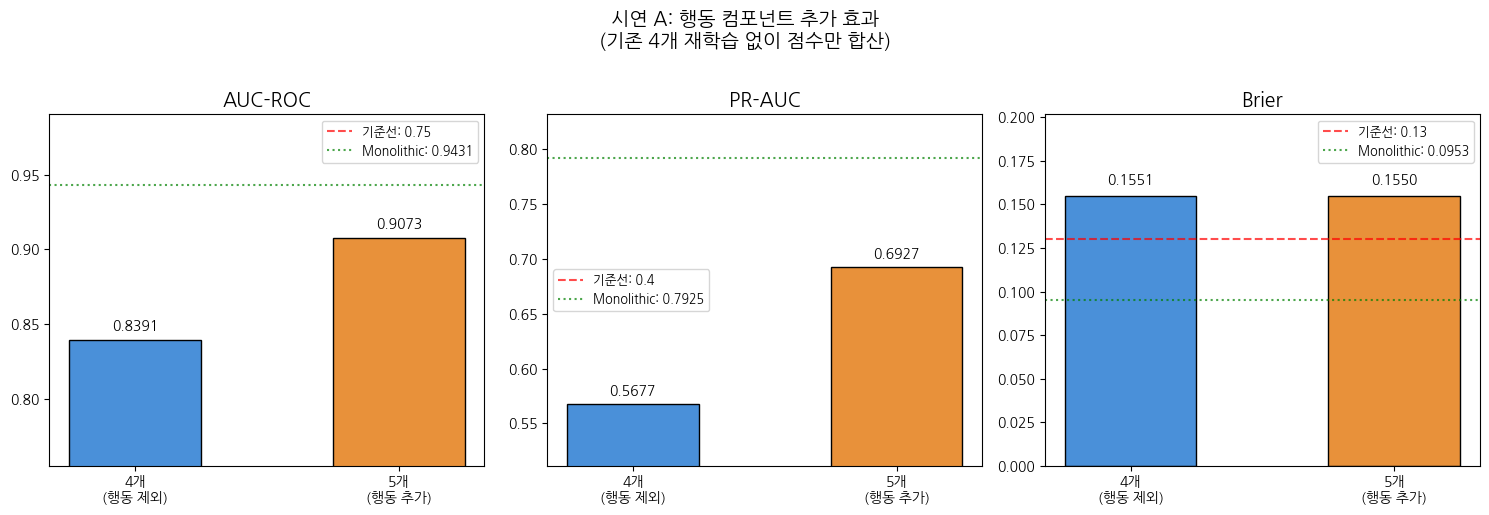

In [12]:
# ─── 시각화: 4개 vs 5개 비교 ───

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_names = ["AUC-ROC", "PR-AUC", "Brier"]
colors = ["#4A90D9", "#E8913A"]

for i, metric in enumerate(metrics_names):
    vals = [metrics_4_eval[metric], metrics_5_eval[metric]]
    bars = axes[i].bar(["4개\n(행동 제외)", "5개\n(행동 추가)"], vals, color=colors, edgecolor="black", width=0.5)

    # 기준선 표시
    if metric in baselines:
        axes[i].axhline(y=baselines[metric], color="red", linestyle="--", alpha=0.7, label=f"기준선: {baselines[metric]}")
    # Monolithic 참고선 (실측치)
    axes[i].axhline(y=metrics_mono[metric], color="green", linestyle=":", alpha=0.7, label=f"Monolithic: {metrics_mono[metric]:.4f}")

    # 값 표시
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f"{val:.4f}", ha='center', va='bottom', fontweight='bold')

    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].legend(fontsize=9)

    # y축 범위 조정
    if metric == "Brier":
        axes[i].set_ylim(0, max(vals) * 1.3)
    else:
        axes[i].set_ylim(min(vals) * 0.9, max(max(vals), metrics_mono[metric]) * 1.05)

plt.suptitle("시연 A: 행동 컴포넌트 추가 효과\n(기존 4개 재학습 없이 점수만 합산)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 시연 D: Graceful Degradation (점진적 성능 저하)

> 컴포넌트를 하나씩 빼도 모델이 **급격히 무너지지 않는가?**

- Additive: 해당 도메인 점수를 **빼기만** 하면 됨 (다른 컴포넌트 그대로)
- Monolithic: feature 빼려면 **전체 재학습** 필요

In [13]:
# ─── 시연 D: 컴포넌트를 하나씩 빼면서 성능 변화 측정 ───

# 먼저 5개 전체로 학습 (이미 위에서 했으므로 scores_full 사용)
# 각 도메인을 하나씩 제외했을 때의 성능을 계산

degradation_results = {}

# 5개 전체 (기준)
total_score_full = sum(scores_full[d] for d in ALL_DOMAINS)
y_pred_full = sigmoid(total_score_full)
degradation_results["5개 전체"] = evaluate(y_test.values, y_pred_full)

# 각 도메인을 하나씩 제외
for remove_domain in ALL_DOMAINS:
    remaining = [d for d in ALL_DOMAINS if d != remove_domain]
    partial_score = sum(scores_full[d] for d in remaining)
    y_pred_partial = sigmoid(partial_score)
    label = f"- {remove_domain}"
    degradation_results[label] = evaluate(y_test.values, y_pred_partial)

# 결과 출력
print("=" * 65)
print("  시연 D: Graceful Degradation")
print("=" * 65)
print(f"{'구성':30s} {'AUC-ROC':>10s} {'PR-AUC':>10s} {'Brier':>10s}")
print("-" * 65)
for label, m in degradation_results.items():
    print(f"{label:30s} {m['AUC-ROC']:>10.4f} {m['PR-AUC']:>10.4f} {m['Brier']:>10.4f}")
print("-" * 65)
print("→ 하나를 빼도 급격한 성능 하락 없이 점진적으로 저하")

  시연 D: Graceful Degradation
구성                                AUC-ROC     PR-AUC      Brier
-----------------------------------------------------------------
5개 전체                              0.9073     0.6927     0.1550
- demographics_uw                  0.8683     0.5887     0.1590
- medical                          0.9106     0.7057     0.1458
- claim                            0.9080     0.6978     0.1449
- policy                           0.9100     0.7022     0.1433
- behavior                         0.8391     0.5677     0.1551
-----------------------------------------------------------------
→ 하나를 빼도 급격한 성능 하락 없이 점진적으로 저하


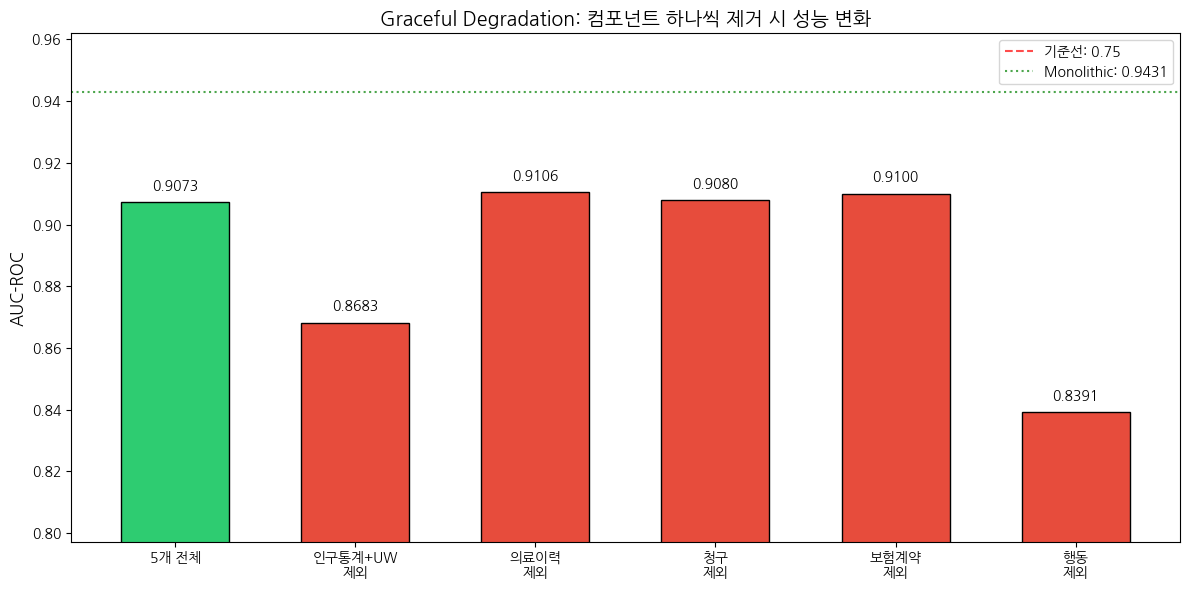

In [14]:
# ─── 시각화: Graceful Degradation ───

domain_labels_kr = {
    "demographics_uw": "인구통계+UW",
    "medical": "의료이력",
    "claim": "청구",
    "policy": "보험계약",
    "behavior": "행동",
}

fig, ax = plt.subplots(figsize=(12, 6))

labels = ["5개 전체"]
auc_values = [degradation_results["5개 전체"]["AUC-ROC"]]
colors_bar = ["#2ECC71"]  # 초록 (전체)

for domain in ALL_DOMAINS:
    key = f"- {domain}"
    labels.append(f"{domain_labels_kr[domain]}\n제외")
    auc_values.append(degradation_results[key]["AUC-ROC"])
    colors_bar.append("#E74C3C")  # 빨강 (제외)

bars = ax.bar(labels, auc_values, color=colors_bar, edgecolor="black", width=0.6)

# 기준선
ax.axhline(y=baselines["AUC-ROC"], color="red", linestyle="--", alpha=0.7, label=f"기준선: {baselines['AUC-ROC']}")
# Monolithic (실측치)
ax.axhline(y=metrics_mono["AUC-ROC"], color="green", linestyle=":", alpha=0.7, label=f"Monolithic: {metrics_mono['AUC-ROC']:.4f}")

# 값 표시
for bar, val in zip(bars, auc_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel("AUC-ROC", fontsize=12)
ax.set_title("Graceful Degradation: 컴포넌트 하나씩 제거 시 성능 변화", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(min(auc_values) * 0.95, max(max(auc_values), metrics_mono["AUC-ROC"]) * 1.02)

plt.tight_layout()
plt.show()

---

## 6. 설명가능성 — Monolithic은 못 하는 것

> "왜 이 사람이 고위험인가?"

- Monolithic: 64개 feature → 블랙박스 → "트리 500개가 종합 판단했습니다" → **설명 불가**
- Additive: 각 도메인이 **얼마나 기여했는지** 숫자로 바로 분해 가능

In [15]:
# ─── 개별 예측 설명: 고위험 vs 저위험 케이스 비교 ───

# 전체 예측 확률 계산
total_score_all = sum(scores_full[d] for d in ALL_DOMAINS)
y_pred_all = sigmoid(total_score_all)

# 고위험 / 저위험 케이스 찾기
high_risk_idx = np.argmax(y_pred_all)  # 가장 높은 확률
low_risk_idx = np.argmin(y_pred_all)   # 가장 낮은 확률

def explain_case(idx, label):
    """특정 케이스의 도메인별 기여도 분해"""
    scores = {}
    total = 0
    for domain in ALL_DOMAINS:
        s = scores_full[domain][idx]
        scores[domain] = s
        total += s
    prob = sigmoid(total)

    print(f"\n{'='*50}")
    print(f"  {label} (index={idx})")
    print(f"{'='*50}")
    for domain in ALL_DOMAINS:
        bar = "+" * max(0, int(scores[domain] * 3)) + "-" * max(0, int(-scores[domain] * 3))
        print(f"  {domain_labels_kr[domain]:12s}: {scores[domain]:+7.3f}  {bar}")
    print(f"  {'합산':12s}: {total:+7.3f} → 확률: {prob:.4f}")
    print(f"  실제 정답   : {'양성 (고비용)' if y_test.values[idx] == 1 else '음성'}")
    return scores

scores_high = explain_case(high_risk_idx, "고위험 케이스")
scores_low = explain_case(low_risk_idx, "저위험 케이스")


  고위험 케이스 (index=112085)
  인구통계+UW     :  +3.300  +++++++++
  의료이력        :  +0.026  
  청구          :  -0.755  --
  보험계약        :  -1.441  ----
  행동          :  +4.086  ++++++++++++
  합산          :  +5.216 → 확률: 0.9946
  실제 정답   : 양성 (고비용)

  저위험 케이스 (index=98169)
  인구통계+UW     :  -3.764  -----------
  의료이력        :  -2.015  ------
  청구          :  -2.110  ------
  보험계약        :  -2.694  --------
  행동          :  -6.848  --------------------
  합산          : -17.430 → 확률: 0.0000
  실제 정답   : 음성


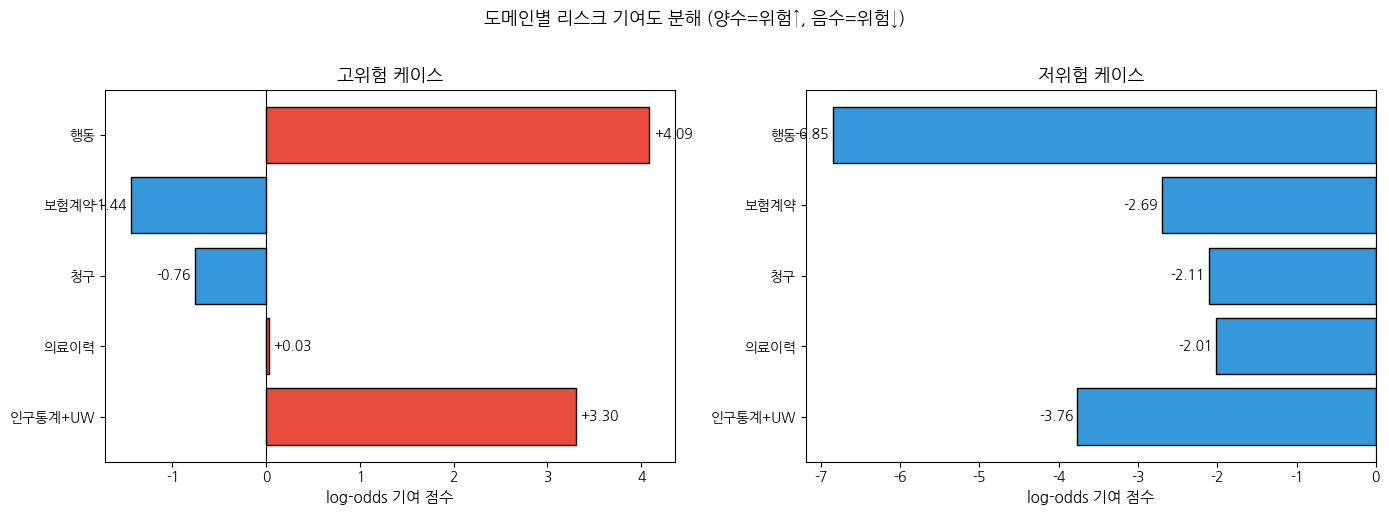

In [16]:
# ─── 시각화: 고위험 vs 저위험 기여도 비교 ───

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

domain_names = [domain_labels_kr[d] for d in ALL_DOMAINS]

for ax, scores, title in [(axes[0], scores_high, "고위험 케이스"),
                           (axes[1], scores_low, "저위험 케이스")]:
    vals = [scores[d] for d in ALL_DOMAINS]
    colors_h = ["#E74C3C" if v > 0 else "#3498DB" for v in vals]

    bars = ax.barh(domain_names, vals, color=colors_h, edgecolor="black")
    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.set_xlabel("log-odds 기여 점수", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')

    # 값 표시
    for bar, val in zip(bars, vals):
        x_pos = val + 0.05 if val >= 0 else val - 0.05
        ha = 'left' if val >= 0 else 'right'
        ax.text(x_pos, bar.get_y() + bar.get_height()/2,
                f"{val:+.2f}", ha=ha, va='center', fontsize=10)

plt.suptitle("도메인별 리스크 기여도 분해 (양수=위험↑, 음수=위험↓)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 도메인별 평균 기여도 — 양성 vs 음성 비교

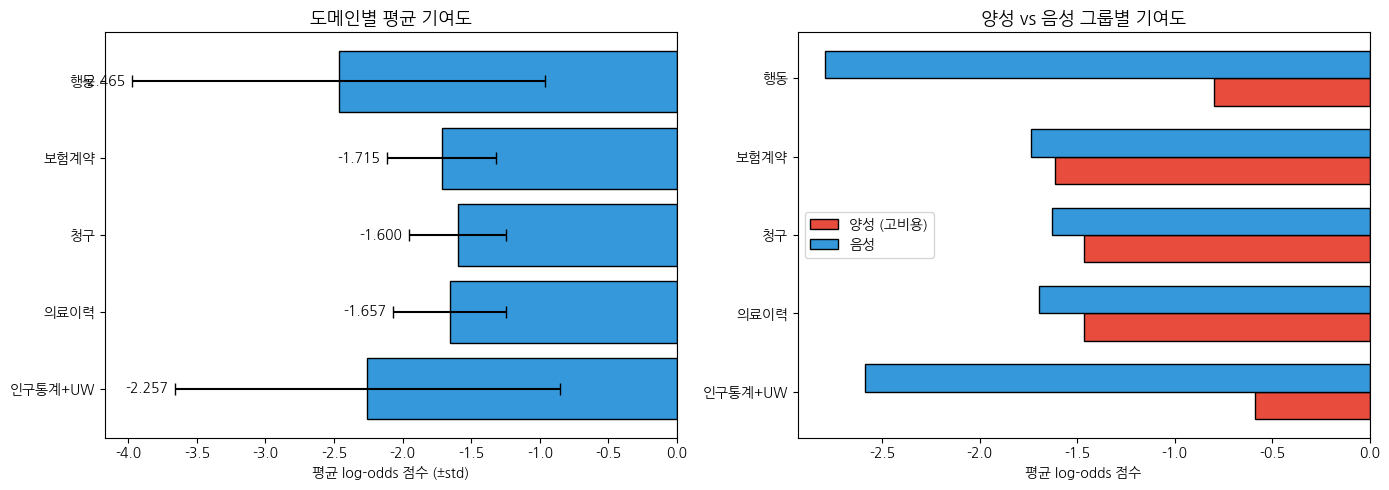

In [17]:
# ─── 도메인별 평균 기여도 + 분포 ───

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 평균 기여도 막대 그래프
means = [scores_full[d].mean() for d in ALL_DOMAINS]
stds = [scores_full[d].std() for d in ALL_DOMAINS]
colors_mean = ["#E74C3C" if m > 0 else "#3498DB" for m in means]

axes[0].barh(domain_names, means, xerr=stds, color=colors_mean,
             edgecolor="black", capsize=4)
axes[0].axvline(x=0, color="black", linewidth=0.8)
axes[0].set_xlabel("평균 log-odds 점수 (±std)")
axes[0].set_title("도메인별 평균 기여도", fontsize=13, fontweight='bold')

for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(m + s + 0.05 if m >= 0 else m - s - 0.05, i,
                 f"{m:+.3f}", ha='left' if m >= 0 else 'right', va='center', fontsize=10)

# 오른쪽: 양성 vs 음성 그룹별 평균 기여도
y_test_arr = y_test.values
pos_mask = y_test_arr == 1
neg_mask = y_test_arr == 0

x = np.arange(len(ALL_DOMAINS))
width = 0.35

pos_means = [scores_full[d][pos_mask].mean() for d in ALL_DOMAINS]
neg_means = [scores_full[d][neg_mask].mean() for d in ALL_DOMAINS]

axes[1].barh(x - width/2, pos_means, width, label="양성 (고비용)", color="#E74C3C", edgecolor="black")
axes[1].barh(x + width/2, neg_means, width, label="음성", color="#3498DB", edgecolor="black")
axes[1].set_yticks(x)
axes[1].set_yticklabels(domain_names)
axes[1].axvline(x=0, color="black", linewidth=0.8)
axes[1].set_xlabel("평균 log-odds 점수")
axes[1].set_title("양성 vs 음성 그룹별 기여도", fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

---

## 7. 결론: Monolithic vs Modular

| | Monolithic | Additive (Modular) |
|---|---|---|
| **성능** | 직접 비교 (위 결과) | 직접 비교 (위 결과) |
| **새 도메인 추가** | 전체 재학습 필요 | 새 컴포넌트 점수만 합산 |
| **부분 제거/중단** | 전체 재학습 필요 | 해당 점수만 빼면 됨 |
| **설명가능성** | 블랙박스 | 도메인별 기여도 분해 |
| **독립 검증** | 불가 | 컴포넌트별 독립 감사 가능 |
| **규제 적합성** | 낮음 | 높음 |

> **성능은 비슷하지만, 모듈형만이 확장·설명·부분중단이 가능하다.**